# Qubit States and the Bloch Sphere



This session connects the mathematics of the previous two notebooks to actual quantum states. Everything we practiced with NumPy, vectors, norms, inner products, tensor products, now becomes physical.

We cover seven topics.

1. Representing qubit states as vectors
2. Visualizing states on the Bloch sphere
3. The single qubit gate zoo
4. Preparing states with Ry and Rz rotations



In [26]:
%pip install qiskit qiskit-aer matplotlib numpy
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
from qiskit_aer import AerSimulator

Note: you may need to restart the kernel to use updated packages.


## 1. Representing Qubit States as Vectors

A qubit state is a vector in $\mathbb{C}^2$ with norm one. The general form is

$$|\psi\rangle = \alpha|0\rangle + \beta|1\rangle, \qquad |\alpha|^2 + |\beta|^2 = 1$$

The numbers $\alpha$ and $\beta$ are the probability amplitudes we met in the mathematics notebook. Qiskit stores this vector for us, and we can extract it at any point using `Statevector`.

In [27]:


qc = QuantumCircuit(1)


state = Statevector(qc)
print(state.data)

[1.+0.j 0.+0.j]


The output is exactly the column vector $\begin{pmatrix} 1 \\ 0 \end{pmatrix}$ written as a NumPy array. Qiskit and NumPy speak the same language underneath.

In [28]:


qc = QuantumCircuit(1)
qc.h(0)


state = Statevector(qc)
print(state.data)


[0.70710678+0.j 0.70710678+0.j]


## 2. The Bloch Sphere

Any single qubit state can be written as

$$|\psi\rangle = \cos\frac{\theta}{2}|0\rangle + e^{i\phi}\sin\frac{\theta}{2}|1\rangle$$

Two angles, $\theta$ and $\phi$, fully describe the state. This means every single qubit state is a point on the surface of a sphere, called the Bloch sphere.

The north pole is $|0\rangle$, the south pole is $|1\rangle$, and the equator holds all equal superpositions, differing only in phase.

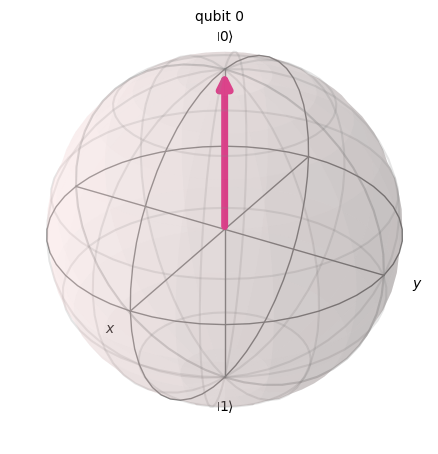

In [29]:
# let us see |0> on the sphere first

qc = QuantumCircuit(1)
state = Statevector(qc)


plot_bloch_multivector(state)

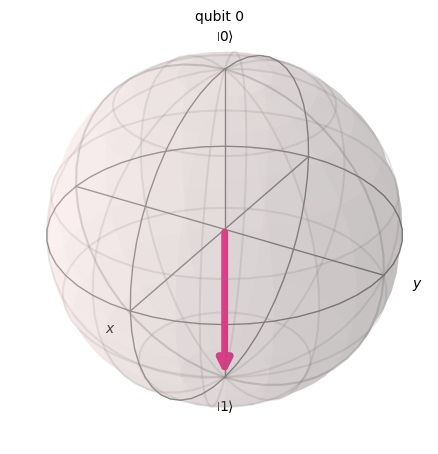

In [30]:
# now apply X, the bit flip gate
# on the board: X swaps |0> and |1>

qc = QuantumCircuit(1)
qc.x(0)

state = Statevector(qc)


plot_bloch_multivector(state)

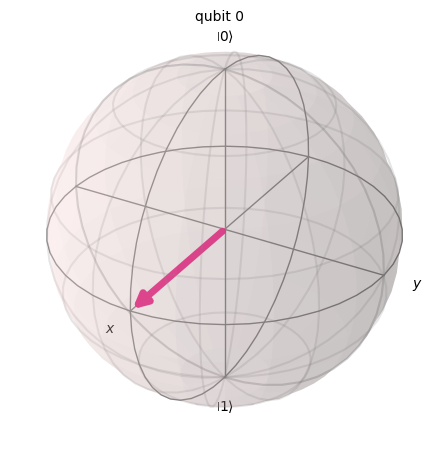

In [31]:
# and the Hadamard superposition we built earlier

qc = QuantumCircuit(1)
qc.h(0)
state = Statevector(qc)


plot_bloch_multivector(state)

Three states, three points on the sphere. The key insight to repeat to the class, the sphere is not a probability picture, it is a state picture. Two states on opposite sides of the equator have identical measurement probabilities but are different states. We will prove that with Rz shortly.

## 3. The Single Qubit Gate Zoo

Every single qubit gate is a two by two unitary matrix, and applying a gate to a state is nothing more than the matrix times vector multiplication from the NumPy notebook. There is also a beautiful geometric fact hiding underneath, every single qubit gate is a rotation of the Bloch sphere. Different gates rotate around different axes by different angles, but that is the entire zoo in one sentence.

Here is the full family we will meet in this section.

| Gate | Matrix | What it does |
|------|--------|--------------|
| $I$ | $\begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix}$ | Does nothing, the do nothing gate |
| $X$ | $\begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}$ | Bit flip, rotation by $\pi$ around the x axis |
| $Y$ | $\begin{pmatrix} 0 & -i \\ i & 0 \end{pmatrix}$ | Bit flip and phase flip, rotation by $\pi$ around the y axis |
| $Z$ | $\begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix}$ | Phase flip, rotation by $\pi$ around the z axis |
| $H$ | $\frac{1}{\sqrt{2}}\begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}$ | Creates and undoes superposition |
| $S$ | $\begin{pmatrix} 1 & 0 \\ 0 & i \end{pmatrix}$ | Quarter turn around z, the square root of Z |
| $T$ | $\begin{pmatrix} 1 & 0 \\ 0 & e^{i\pi/4} \end{pmatrix}$ | Eighth turn around z, the square root of S |
| $R_x, R_y, R_z$ | rotation matrices | Turn by any chosen angle around x, y, or z |

We will look at each one on the Bloch sphere, and we will use one new tool, `Operator`, which prints the matrix of any gate or circuit so the class can see the linear algebra directly.

### The Pauli X gate, the bit flip

We already saw X send $|0\rangle$ to the south pole. But X has a secret worth demonstrating, connected to the eigenvectors we computed in the NumPy notebook. There we found that the eigenvectors of the X matrix were the $|+\rangle$ and $|-\rangle$ states. An eigenvector is a vector a matrix cannot turn, so X should leave $|+\rangle$ exactly where it is.

[0.70710678+0.j 0.70710678+0.j]


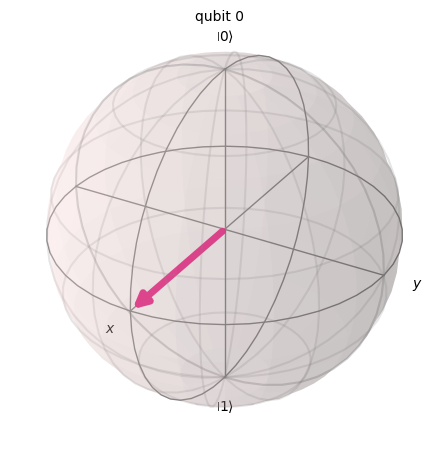

In [32]:
# build |+> with a Hadamard, then hit it with X

qc = QuantumCircuit(1)
qc.h(0)
qc.x(0)

state = Statevector(qc)


print(state.data)
plot_bloch_multivector(state)



### The Pauli Z gate, the phase flip

Z leaves $|0\rangle$ and $|1\rangle$ untouched apart from a sign, so on its own poles it is invisible. The action becomes visible on the equator.

$$Z|+\rangle = \frac{1}{\sqrt{2}}\big(|0\rangle - |1\rangle\big) = |-\rangle$$

In [33]:


qc = QuantumCircuit(1)
qc.z(0)


state = Statevector(qc)
print(state.data)



[1.+0.j 0.+0.j]


[ 0.70710678+0.j -0.70710678+0.j]


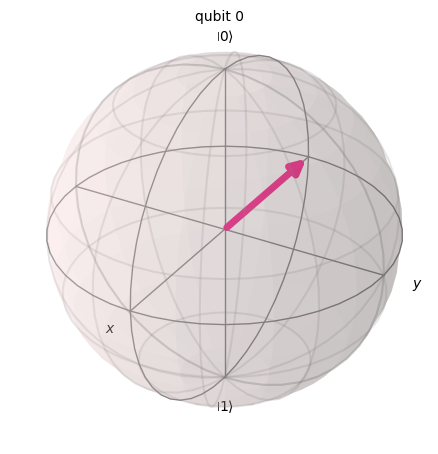

In [34]:


qc = QuantumCircuit(1)
qc.h(0)
qc.z(0)

state = Statevector(qc)


print(state.data)
plot_bloch_multivector(state)



### The Pauli Y gate, both flips at once

Y is the least intuitive of the three Pauli gates because its matrix contains $i$. The simplest way to hold it in your head, Y does what X and Z do together, a bit flip and a phase flip in one move, which geometrically is a half turn around the y axis.

[0.+0.j 0.+1.j]


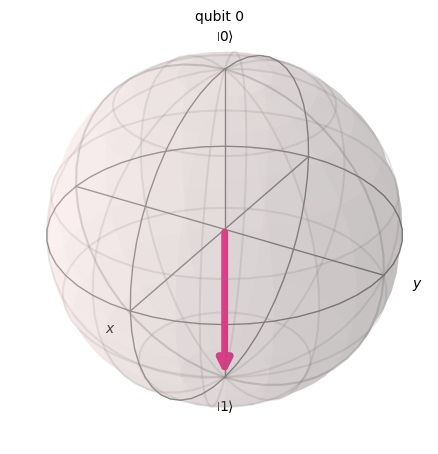

In [35]:
# print the matrix first, the class should see the i entries

qc = QuantumCircuit(1)
qc.y(0)


# now apply Y to |0>
state = Statevector(qc)


print(state.data)
plot_bloch_multivector(state)


### The Hadamard gate, the basis changer

H is the gate that moves between the pole picture and the equator picture. It sends $|0\rangle$ to $|+\rangle$ and $|1\rangle$ to $|-\rangle$, and, crucially, it undoes itself.

$$H^2 = I$$

Geometrically H is a half turn around a tilted axis lying halfway between x and z, which is why applying it twice brings every state home.

[1.+0.j 0.+0.j]


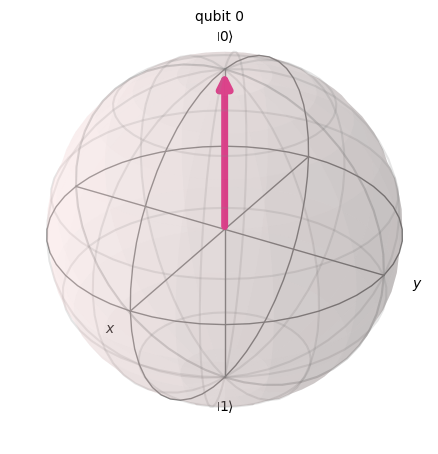

In [ ]:
# apply H twice in a row

qc = QuantumCircuit(1)
qc.h(0)
qc.h(0)

state = Statevector(qc)


print(state.data)


plot_bloch_multivector(state)



### The phase gates S and T

S and T live entirely on the z axis, they are gentler versions of Z.

$$S = \begin{pmatrix} 1 & 0 \\ 0 & i \end{pmatrix}, \qquad T = \begin{pmatrix} 1 & 0 \\ 0 & e^{i\pi/4} \end{pmatrix}$$

Z is a half turn around z, S is a quarter turn, T is an eighth of a turn. That gives the memorable ladder

$$T^2 = S, \qquad S^2 = Z$$

The T gate looks humble but it is the gate that, together with H, unlocks universal quantum computation later in the course.

Bloch S gate:


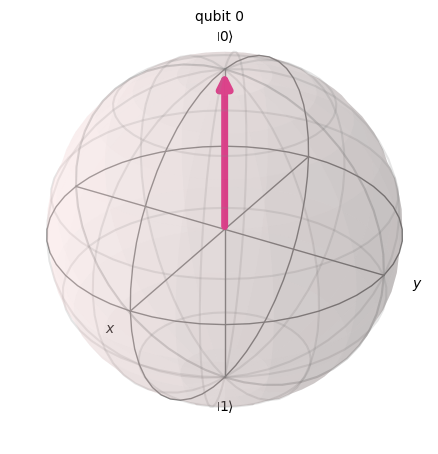

In [47]:
# claim on the board: two S gates equal one Z gate
# let us prove it with matrices, live

qc_two_s = QuantumCircuit(1)
qc_two_s.s(0)
stateS = Statevector(qc_two_s)



print("Bloch S gate:")
plot_bloch_multivector(stateS)





Bloch T gate:


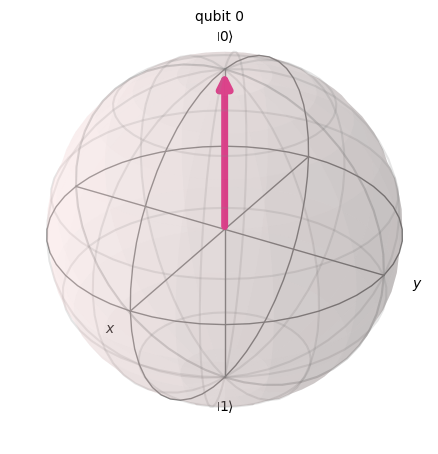

In [48]:
qc_one_t = QuantumCircuit(1)
qc_one_t.t(0)
stateT = Statevector(qc_one_t)

print("Bloch T gate:")
plot_bloch_multivector(stateT)

[0.70710678+0.j         0.        +0.70710678j]


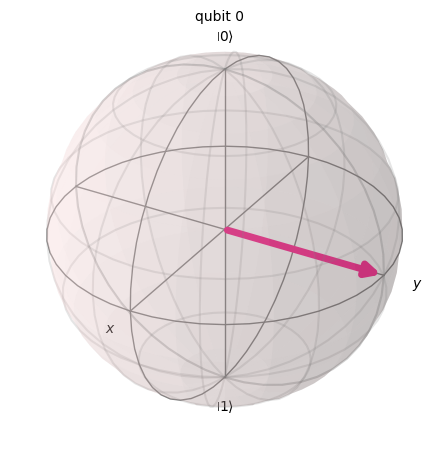

In [ ]:


qc = QuantumCircuit(1)
qc.h(0)
qc.t(0)

state = Statevector(qc)


print(state.data)
plot_bloch_multivector(state)


### The Rx gate, completing the rotation family

We will meet Ry and Rz in depth in the next section. Rx is their sibling, rotation by any chosen angle around the x axis. There is a satisfying family reunion here, the Pauli gates are just the rotation gates dialed to exactly half a turn. For example $R_x(\pi)$ is the X gate, up to an unmeasurable global phase.

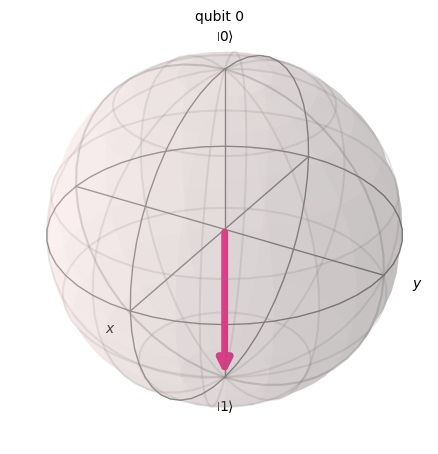

In [39]:
# claim: Rx at angle pi is the X gate in disguise

qc_rx = QuantumCircuit(1)
qc_rx.rx(np.pi, 0)




state_rx = Statevector(qc_rx)
plot_bloch_multivector(state_rx)



## 4. Preparing States with Ry and Rz

The gates X and H only reach a handful of special points. To reach any point on the Bloch sphere we use rotation gates.

The Ry gate rotates the state around the y axis by an angle $\theta$,

$$R_y(\theta)|0\rangle = \cos\frac{\theta}{2}|0\rangle + \sin\frac{\theta}{2}|1\rangle$$

The Rz gate rotates around the z axis by an angle $\phi$, changing only the phase between the amplitudes.

Together, Ry sets the latitude and Rz sets the longitude. Any single qubit state can be prepared with one Ry followed by one Rz.

[0.8660254+0.j 0.5      +0.j]


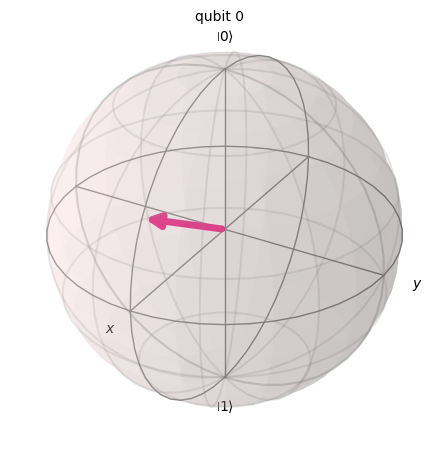

In [40]:
# start from |0> and rotate by 60 degrees, which is pi / 3

theta = np.pi / 3

qc = QuantumCircuit(1)
qc.ry(theta, 0)

state = Statevector(qc)


print(state.data)


plot_bloch_multivector(state)

[0.61237244-0.61237244j 0.35355339+0.35355339j]


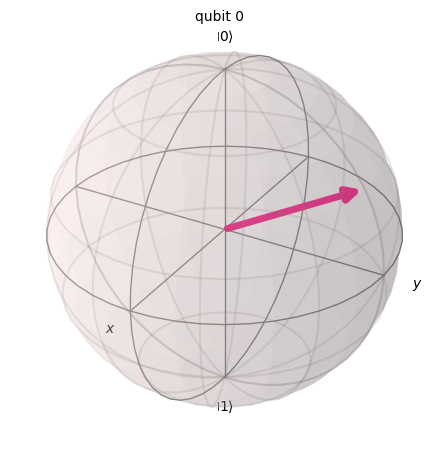

In [41]:


theta = np.pi / 3
phi   = np.pi / 2

qc = QuantumCircuit(1)
qc.ry(theta, 0)
qc.rz(phi, 0)

state = Statevector(qc)

print(state.data)



plot_bloch_multivector(state)

The arrow moved sideways around the sphere but kept the same height. This is the visual proof that phase is invisible to a single measurement in the computational basis, yet the state itself genuinely changed. Interference experiments later in the course will make this phase visible.